In [1]:
import numpy
import torchvision

train = torchvision.datasets.MNIST("mnist", train=True, download=True)
test = torchvision.datasets.MNIST("mnist", train=False, download=True)

train_images = numpy.array([numpy.array(item[0]) / 255 for item in train])
train_labels = numpy.array([item[1] for item in train])

test_images = numpy.array([numpy.array(item[0]) / 255 for item in test])
test_labels = numpy.array([item[1] for item in test])

In [2]:
import cvtda.topology

fe = cvtda.topology.FeatureExtractor(
    settings=cvtda.topology.FeatureExtractor.Settings(
        greyscale=cvtda.topology.GreyscaleExtractor.PRESETS.reduced,
        inverted=cvtda.topology.GreyscaleExtractor.PRESETS.reduced,
        filtrations=cvtda.topology.FiltrationsExtractor.PRESETS.reduced,
        point_clouds=cvtda.topology.PointCloudsExtractor.PRESETS.reduced,
        geometry=cvtda.topology.GeometryExtractor.Settings(
            rgb=cvtda.topology.RGBGeometryExtractor.Settings(enabled=False),
            gray=cvtda.topology.GrayGeometryExtractor.Settings(enabled=False),
            multidimensional=cvtda.topology.MultidimensionalGeometryExtractor.Settings(enabled=False),
        ),
    )
)
train_features = fe.fit_transform(train_images, dump_name = 'mnist/train')
test_features = fe.transform(test_images, dump_name = 'mnist/test')

GreyscaleExtractor: processing mnist/train/greyscale, do_fit = True
Got the result from ./mnist/train/greyscale/diagrams.npy
Applying Scaler to persistence diagrams.
DiagramVectorizer: fitting complete
Got the result from ./mnist/train/greyscale/features.npy
GreyscaleExtractor: processing mnist/train/inverted_greyscale, do_fit = True
Got the result from ./mnist/train/inverted_greyscale/diagrams.npy
Applying Scaler to persistence diagrams.
DiagramVectorizer: fitting complete
Got the result from ./mnist/train/inverted_greyscale/features.npy
Fitting filtrations


100%|██████████| 72/72 [00:35<00:00,  2.05it/s]


Got the result from ./mnist/train/geometry/features.npy
Applying StandardScaler.
GreyscaleExtractor: processing mnist/test/greyscale, do_fit = False
Got the result from ./mnist/test/greyscale/diagrams.npy
Applying Scaler to persistence diagrams.
Got the result from ./mnist/test/greyscale/features.npy
GreyscaleExtractor: processing mnist/test/inverted_greyscale, do_fit = False
Got the result from ./mnist/test/inverted_greyscale/diagrams.npy
Applying Scaler to persistence diagrams.
Got the result from ./mnist/test/inverted_greyscale/features.npy
Applying filtrations


100%|██████████| 72/72 [00:10<00:00,  7.20it/s]


Got the result from ./mnist/test/geometry/features.npy
Applying StandardScaler.


In [3]:
import sklearn.tree
import sklearn.metrics

dt = sklearn.tree.DecisionTreeClassifier(max_depth = 10, max_features = 0.1, random_state = 42)
dt.fit(train_features, train_labels)

test_pred = dt.predict(test_features)
sklearn.metrics.accuracy_score(test_pred, test_labels)

0.9247

Target:  6
Prediction:  6
Explaining HeightFiltration with d = (1, -1), bin. thr. = 0.5 -> landscape -> 2:
[[0.         0.         0.        ]
 [1.45328951 2.44039076 1.        ]]
[]
Explaining inverted -> betti -> 5:
[[0.         1.30196078 0.        ]
 [0.         2.         1.        ]
 [1.41176471 1.99215686 1.        ]
 [1.45882353 1.95294118 1.        ]
 [1.54509804 1.99215686 1.        ]
 [1.69411765 1.99215686 1.        ]
 [1.71764706 1.99215686 1.        ]
 [1.7254902  1.99215686 1.        ]
 [1.73333333 1.99215686 1.        ]
 [1.74117647 1.97647059 1.        ]
 [1.78039216 1.99215686 1.        ]
 [1.85098039 1.99215686 1.        ]
 [1.86666667 1.99215686 1.        ]
 [1.89019608 1.99215686 1.        ]
 [1.89019608 1.99215686 1.        ]
 [1.94509804 1.99215686 1.        ]
 [1.97647059 1.99215686 1.        ]
 [1.99215686 2.         1.        ]]
[1 2 3 4 5]
Explaining HeightFiltration with d = (0, -1), bin. thr. = 0.5 -> lifetime -> 11:
[[0.         0.         0.        ]
 [1.

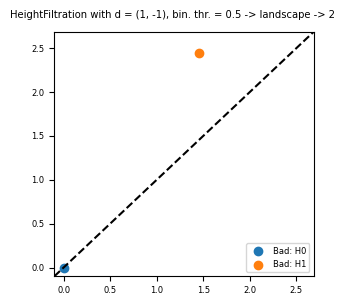

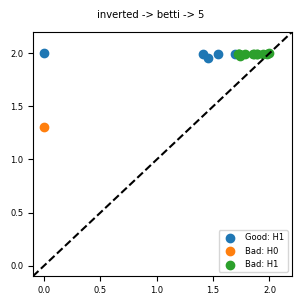

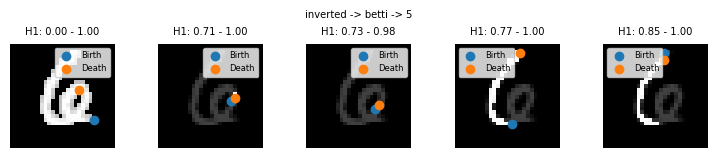

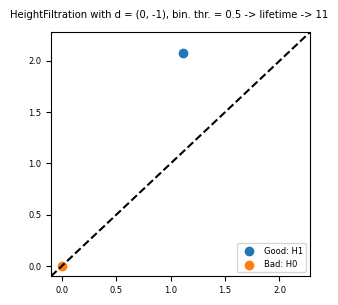

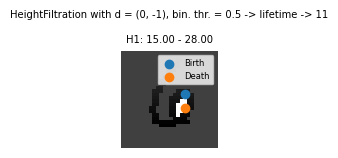

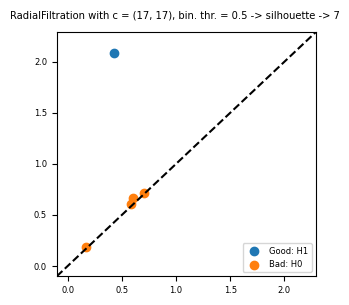

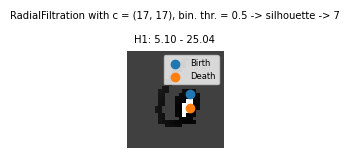

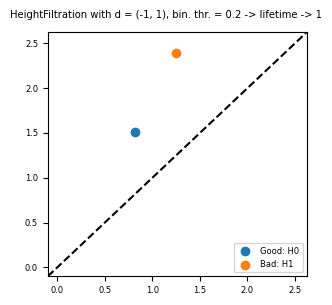

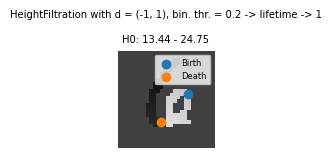

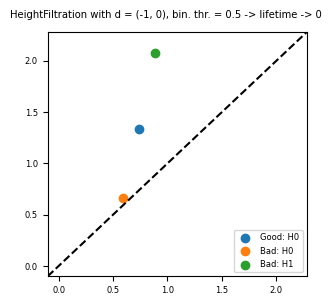

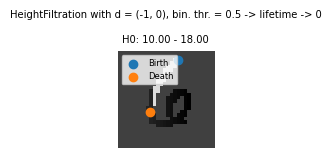

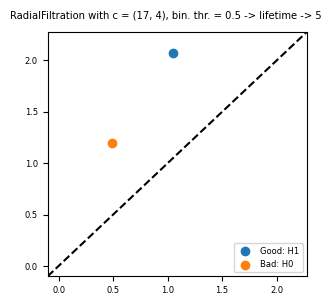

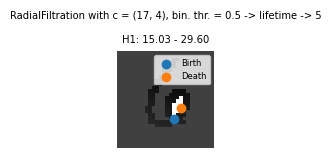

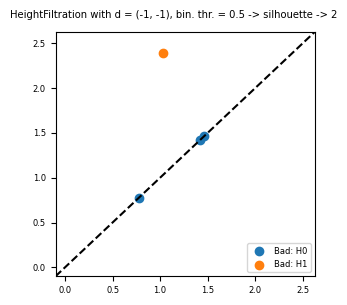

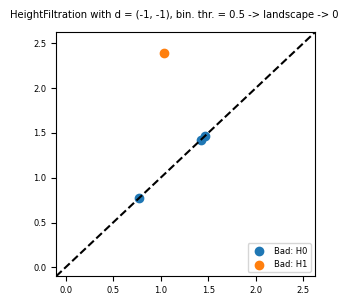

In [20]:
def explain_decision_tree(fe: cvtda.topology.FeatureExtractor, dt: sklearn.tree.DecisionTreeClassifier, obj: int):
    print('Target: ', test_labels[obj])
    print('Prediction: ', dt.predict([ test_features[obj] ])[0])

    path = dt.decision_path([ test_features[obj] ]).toarray()[0]
    features_idxs = dt.tree_.feature[numpy.where(path != 0)[0][:-1]]
    for i, feature in enumerate(numpy.array(fe.feature_names())[features_idxs]):
        fe.explain(feature, test_images[obj]).display(feature)

explain_decision_tree(fe, dt, 123)